<a href="https://colab.research.google.com/github/RytisBalt/DI-kursas/blob/Dirbtinis4/DirbtinisNr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/Data', batch_size=64, image_size=(128,128))
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()


Found 1852 files belonging to 2 classes.


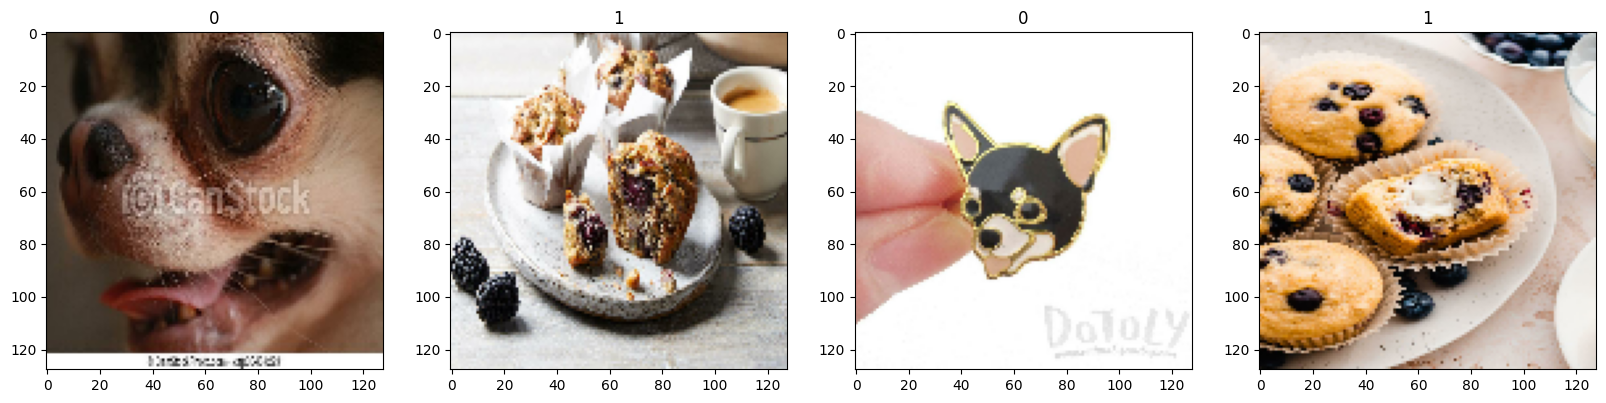

In [ ]:
#0 - Šuniukai
#1 - Keksiukai
len(batch)
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
batch[0].max()

255.0

In [ ]:
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()

(array([[[[0.3075827 , 0.33111215, 0.323269  ],
          [0.30511642, 0.32864583, 0.3208027 ],
          [0.3202359 , 0.34376532, 0.33592218],
          ...,
          [0.36567095, 0.3578278 , 0.310769  ],
          [0.35055146, 0.34270832, 0.2956495 ],
          [0.33211467, 0.32427153, 0.2772127 ]],
 
         [[0.34134498, 0.3648744 , 0.35703126],
          [0.33514106, 0.35867047, 0.35082734],
          [0.3500766 , 0.373606  , 0.36576286],
          ...,
          [0.327788  , 0.30033702, 0.26112133],
          [0.31994486, 0.29249388, 0.2532782 ],
          [0.31210172, 0.28465074, 0.24543504]],
 
         [[0.36868525, 0.40808475, 0.40407127],
          [0.36078432, 0.40018383, 0.39617035],
          [0.3646926 , 0.4040921 , 0.40007862],
          ...,
          [0.3137255 , 0.2901961 , 0.24313726],
          [0.30588236, 0.28235295, 0.23529412],
          [0.29405984, 0.27053043, 0.22347161]],
 
         ...,
 
         [[0.66447204, 0.51554435, 0.32311174],
          [0.66955

In [ ]:
train_size = int(len(data)*.8)
val_size = int(len(data)*.1) + 1
test_size = int(len(data)*.1) + 1

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
optimizer = Adam(learning_rate=0.001)
def pirmas_modelis(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')])
    return model
model1 = pirmas_modelis((128,128,3))
model1.compile(optimizer=optimizer, loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 246016)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      31,490,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,509,697 (120.20 MB)

 Trainable params: 31,509,697 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=0.001)
def antras_modelis(input_shape):
    model = Sequential([
      Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
      MaxPooling2D(pool_size=(2, 2)),
      Conv2D(16, kernel_size=(3, 3), activation='relu'),
      MaxPooling2D(pool_size=(2, 2)),
      Flatten(),
      Dense(128, activation='relu'),
      Dense(1, activation='sigmoid')])

    return model


model2 = antras_modelis((128,128,3))
model2.compile(optimizer=optimizer, loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 61, 61, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,843,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,848,977 (7.05 MB)

 Trainable params: 1,848,977 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=0.001)
#optimizer = SGD(learning_rate=0.001, momentum=0.9)
def trecias_modelis(input_shape):
    modelis = Sequential([
        Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        #BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        #BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        #Dropout(0.35),
        Conv2D(16, kernel_size=(3, 3), activation='relu'),
        #BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        #Dropout(0.45),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
        #Dense(1, activation='softmax')
    ])
    return modelis
model3 = trecias_modelis((128,128,3))
model3.compile(optimizer=optimizer, loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
model3.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 28, 28, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 411,633 (1.57 MB)

 Trainable params: 411,505 (1.57 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:

# Example fit call (train and val need to be defined)
# Note: Adjust `batch_size` and input dimensions of your data accordingly
hist1 = model1.fit(train, epochs=5, validation_data=val, batch_size = 64)

Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 166s 7s/step - accuracy: 0.5051 - loss: 4.7962 - val_accuracy: 0.5833 - val_loss: 0.5731
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 179s 6s/step - accuracy: 0.7116 - loss: 0.5113 - val_accuracy: 0.8594 - val_loss: 0.3123
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.9136 - loss: 0.2478 - val_accuracy: 0.9479 - val_loss: 0.1869
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.9590 - loss: 0.1502 - val_accuracy: 0.9271 - val_loss: 0.1725
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - accuracy: 0.9730 - loss: 0.0926 - val_accuracy: 0.9635 - val_loss: 0.1303


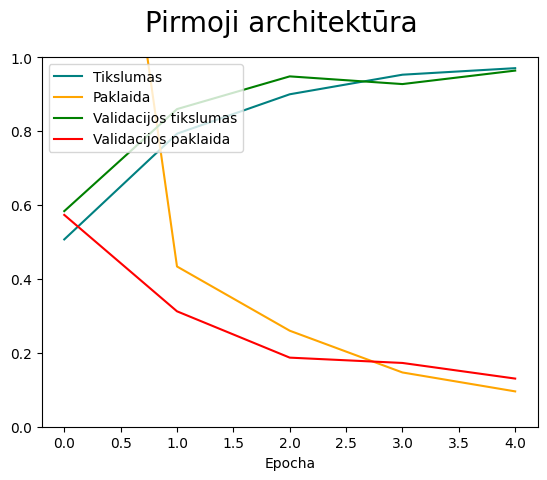

In [ ]:
fig = plt.figure()
plt.plot(hist1.history['accuracy'], color='teal', label='Tikslumas')
plt.plot(hist1.history['loss'], color='orange', label='Paklaida')
plt.plot(hist1.history['val_accuracy'], color='green', label='Validacijos tikslumas')
plt.plot(hist1.history['val_loss'], color='red', label='Validacijos paklaida')
fig.suptitle('Pirmoji architektūra', fontsize=20)
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xlabel('Epocha')
plt.show()

In [ ]:
hist2  = model2.fit(train, epochs=5, validation_data=val, batch_size = 64)

Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5758 - loss: 0.8030 - val_accuracy: 0.7500 - val_loss: 0.5189
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7762 - loss: 0.4719 - val_accuracy: 0.8594 - val_loss: 0.3472
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8513 - loss: 0.3675 - val_accuracy: 0.8333 - val_loss: 0.3588
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8958 - loss: 0.2815 - val_accuracy: 0.8750 - val_loss: 0.2716
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9183 - loss: 0.2237 - val_accuracy: 0.8906 - val_loss: 0.2912


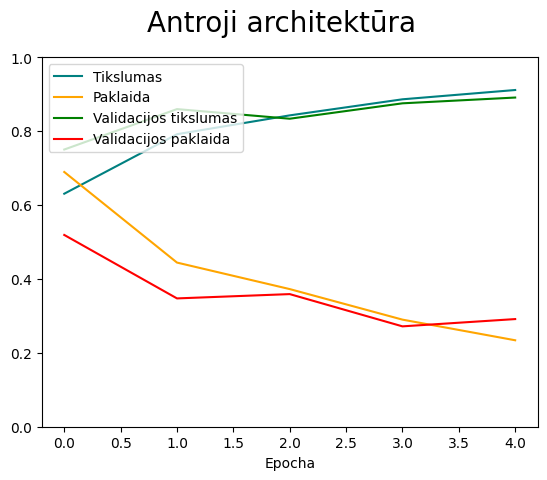

In [ ]:
fig = plt.figure()
plt.plot(hist2.history['accuracy'], color='teal', label='Tikslumas')
plt.plot(hist2.history['loss'], color='orange', label='Paklaida')
plt.plot(hist2.history['val_accuracy'], color='green', label='Validacijos tikslumas')
plt.plot(hist2.history['val_loss'], color='red', label='Validacijos paklaida')
fig.suptitle('Antroji architektūra', fontsize=20)
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xlabel('Epocha')
plt.show()

In [ ]:
hist3 = model3.fit(train, epochs=5, validation_data=val, batch_size = 64)

Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7056 - loss: 0.7336 - val_accuracy: 0.6510 - val_loss: 0.6512
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8923 - loss: 0.2733 - val_accuracy: 0.6510 - val_loss: 0.6228
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9259 - loss: 0.1919 - val_accuracy: 0.5990 - val_loss: 0.6695
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9519 - loss: 0.1284 - val_accuracy: 0.4844 - val_loss: 0.8089
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9757 - loss: 0.0820 - val_accuracy: 0.4688 - val_loss: 1.8479


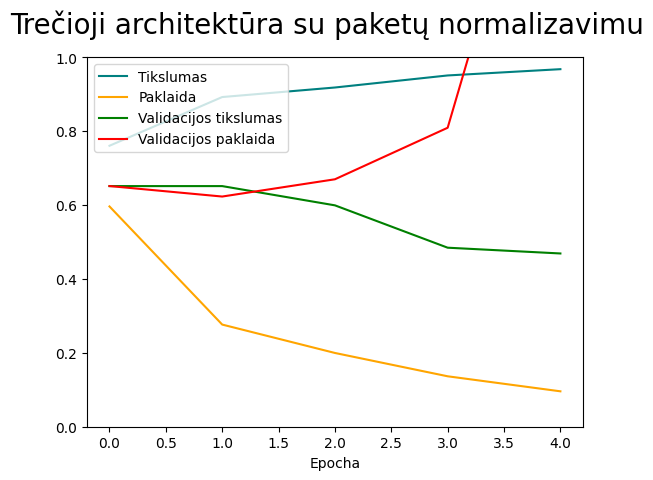

In [ ]:
fig = plt.figure()
plt.plot(hist3.history['accuracy'], color='teal', label='Tikslumas')
plt.plot(hist3.history['loss'], color='orange', label='Paklaida')
plt.plot(hist3.history['val_accuracy'], color='green', label='Validacijos tikslumas')
plt.plot(hist3.history['val_loss'], color='red', label='Validacijos paklaida')
fig.suptitle('Trečioji architektūra su paketų normalizavimu', fontsize=20)
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xlabel('Epocha')
plt.show()

In [ ]:

from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy, TruePositives, TrueNegatives, FalsePositives, FalseNegatives
pre = Precision()
re = Recall()
acc = BinaryAccuracy()
tp = TruePositives()
tn = TrueNegatives()
fp = FalsePositives()
fn = FalseNegatives()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model1.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)
print("Precision", pre.result().numpy(), "Recall", re.result().numpy(), "Tikslumas", acc.result().numpy())

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 924ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step
Precision 0.87777776 Recall 1.0 Tikslumas 0.94148934


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy, TruePositives, TrueNegatives, FalsePositives, FalseNegatives


pre = Precision()
re = Recall()
acc = BinaryAccuracy()
tp = TruePositives()
tn = TrueNegatives()
fp = FalsePositives()
fn = FalseNegatives()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model1.predict(X)
    yhat = (yhat > 0.5).astype(int)

    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)
    tp.update_state(y, yhat)
    tn.update_state(y, yhat)
    fp.update_state(y, yhat)
    fn.update_state(y, yhat)

accuracy = acc.result().numpy()
true_positives = tp.result().numpy()
true_negatives = tn.result().numpy()
false_positives = fp.result().numpy()
false_negatives = fn.result().numpy()

print("Accuracy:", accuracy)
print("True Positives:", true_positives)
print("True Negatives:", true_negatives)
print("False Positives:", false_positives)
print("False Negatives:", false_negatives)

matrica = np.array([[true_positives, false_positives],
                    [false_negatives, true_negatives]])

print("Confusion Matrix:", matrica)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 823ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 805ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step
Precision: 0.93877554
Recall: 1.0
Accuracy: 0.9680851
True Positives: 92.0
True Negatives: 90.0
False Positives: 6.0
False Negatives: 0.0
Confusion Matrix:
 [[92.  6.]
 [ 0. 90.]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


<ipython-input-87-c18d273083e3>:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(yhat > 0.5)  # Convert to 0 or 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

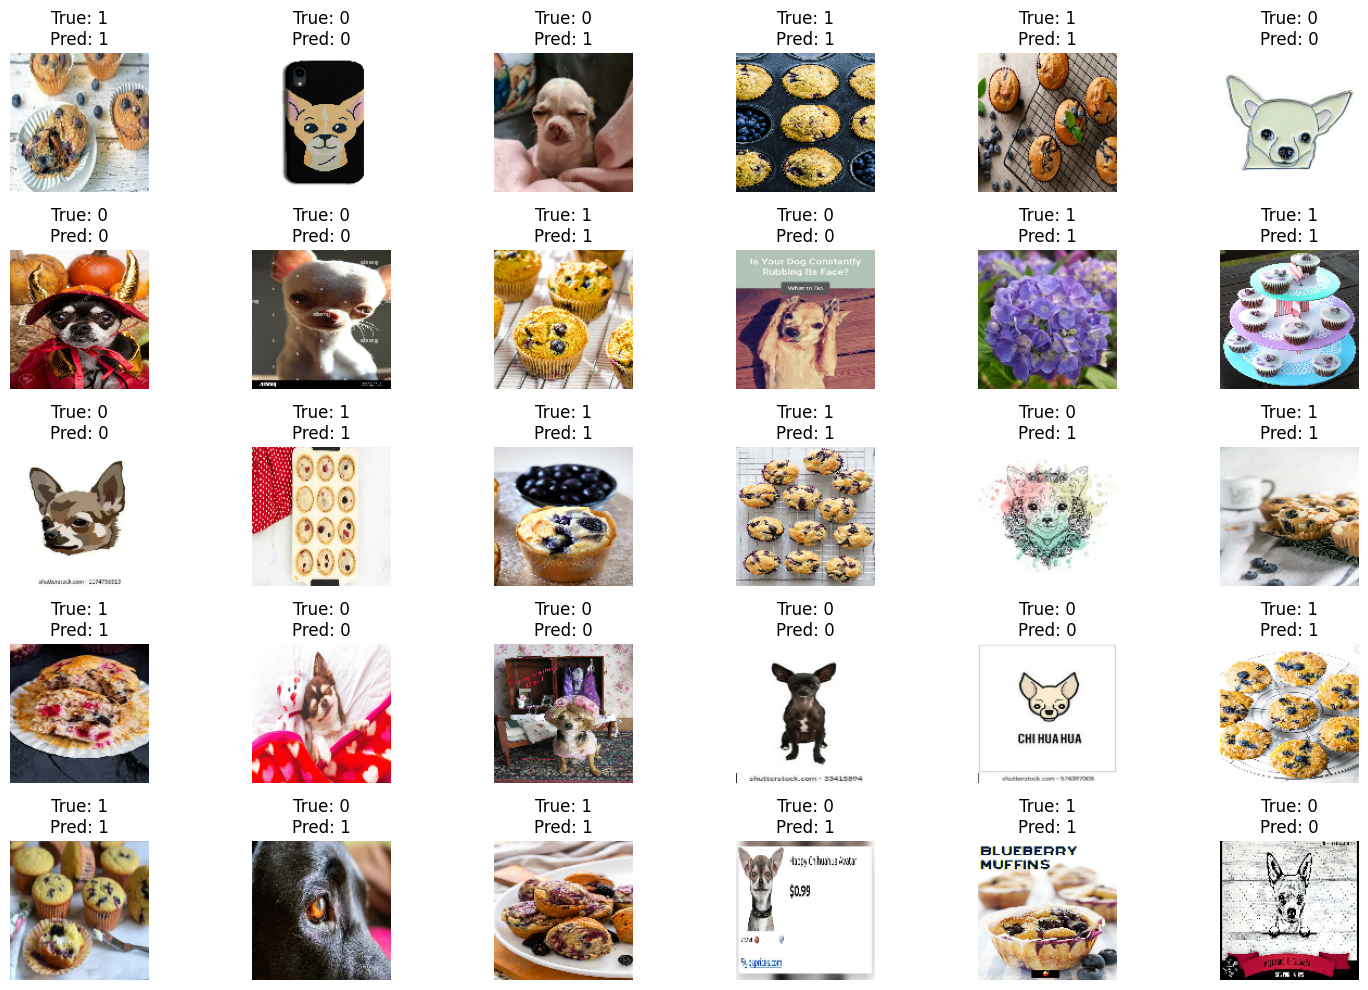

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

samples_to_select = 30
selected_samples = []

for batch in test.as_numpy_iterator():
    X, y = batch
    for i in range(len(X)):
        selected_samples.append((X[i], y[i]))
        if len(selected_samples) >= samples_to_select:
            break
    if len(selected_samples) >= samples_to_select:
        break

results = []
for img, true_label in selected_samples:
    yhat = model1.predict(np.expand_dims(img, axis=0))
    predicted_class = int(yhat > 0.5)
    results.append((img, true_label, predicted_class))

plt.figure(figsize=(15, 10))
for i, (img, true_label, predicted_class) in enumerate(results):
    plt.subplot(5, 6, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.axis('off')
    plt.title(f"True: {int(true_label)}\nPred: {predicted_class}")

plt.tight_layout()
plt.show()
